# 04 — Customer Lifetime Value (CLV) Analysis

Estimates CLV per customer and per segment using a simple historical-value approach, then
identifies where revenue is concentrated and which segment(s) carry the most churn risk.

**Note on approach:** this uses a straightforward historical CLV estimate (average order
value × purchase frequency × estimated customer lifespan) rather than a full predictive CLV
model (e.g. BG/NBD + Gamma-Gamma). This is a deliberate, honest scope choice — a simple,
explainable CLV estimate is more useful for a first version than a complex model that's harder
to justify to a business stakeholder.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
%matplotlib inline

rfm = pd.read_csv("../data/customer_segments.csv")
rfm.head()

,customer_id,recency,frequency,monetary,cluster,segment_name
0,12346,326,1,19780.4878,2,Champions
1,12347,2,7,4310.0000,1,Potential Loyalists
2,12348,75,4,1797.2400,0,At-Risk
3,12349,19,1,1757.5500,0,At-Risk
4,12350,310,1,334.4000,3,New / Low-Engagement


## 1. Estimate CLV

Simple historical CLV formula:

```
Avg Order Value = Monetary / Frequency
CLV = Avg Order Value × Frequency × Estimated Lifespan (years)
```

Since this dataset covers roughly one year, treat observed Monetary value as a proxy for
annual value, and assume a customer relationship lifespan estimate (adjust based on typical
retention in this industry — 3 years is a reasonable illustrative assumption for retail).

In [2]:
ESTIMATED_LIFESPAN_YEARS = 3

rfm["avg_order_value"] = (rfm["monetary"] / rfm["frequency"]).round(2)
rfm["clv"] = (rfm["monetary"] * ESTIMATED_LIFESPAN_YEARS).round(2)

rfm[["customer_id", "segment_name", "monetary", "avg_order_value", "clv"]].head()

,customer_id,segment_name,monetary,avg_order_value,clv
0,12346,Champions,19780.4878,19780.49,59341.46
1,12347,Potential Loyalists,4310.0000,615.71,12930.00
2,12348,At-Risk,1797.2400,449.31,5391.72
3,12349,At-Risk,1757.5500,1757.55,5272.65
4,12350,New / Low-Engagement,334.4000,334.40,1003.20


## 2. Average CLV by Segment

In [3]:
clv_by_segment = rfm.groupby("segment_name").agg(
    customers=("customer_id", "count"),
    avg_clv=("clv", "mean"),
    total_clv=("clv", "sum"),
).round(2).sort_values("avg_clv", ascending=False)

clv_by_segment["pct_of_total_clv"] = (clv_by_segment["total_clv"] / clv_by_segment["total_clv"].sum() * 100).round(1)
clv_by_segment

,customers,avg_clv,total_clv,pct_of_total_clv
segment_name,,,,
Champions,108,45494.91,4913450.62,23.7
Potential Loyalists,556,12900.65,7172761.44,34.6
At-Risk,2636,2756.99,7267432.47,35.1
New / Low-Engagement,1038,1320.43,1370601.87,6.6


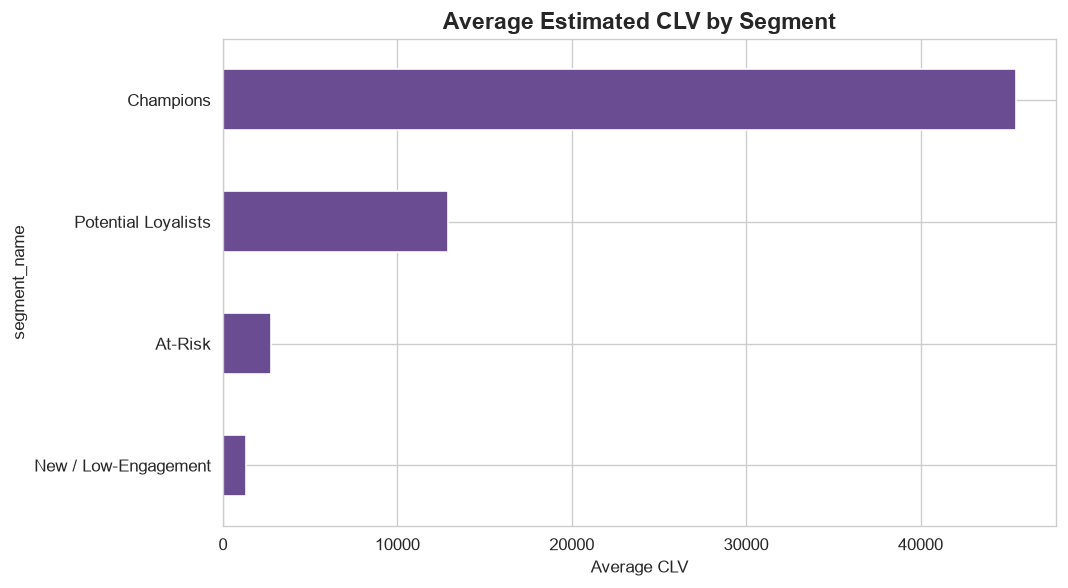

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
clv_by_segment["avg_clv"].sort_values().plot(kind="barh", ax=ax, color="#6A4C93")
ax.set_title("Average Estimated CLV by Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Average CLV")
plt.tight_layout()
plt.savefig("../visuals/clv_by_segment.png", dpi=150)
plt.show()

**Takeaway:** There is a substantial CLV gap between segments — Champions carry an average 
estimated lifetime value roughly 3.5x higher than Potential Loyalists (~₦45,500 vs. ~₦13,000), 
and over 15x higher than At-Risk and New/Low-Engagement customers combined. This gap justifies 
treating segments very differently: retention spend should be heavily concentrated on 
protecting the Champions segment, since losing even a small number of these 108 customers 
represents a disproportionate revenue loss relative to their small share of the customer base. 
At-Risk and New/Low-Engagement customers, by contrast, are better served by low-cost, scalable 
engagement (automated email nurture, small incentive offers) rather than expensive high-touch 
retention efforts that wouldn't be recouped by their spending level.

## 3. Revenue Concentration Check

In [5]:
total_revenue = rfm["monetary"].sum()
rfm_sorted = rfm.sort_values("monetary", ascending=False).reset_index(drop=True)
rfm_sorted["cumulative_revenue_pct"] = rfm_sorted["monetary"].cumsum() / total_revenue * 100
rfm_sorted["customer_rank_pct"] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100

top_10_pct_cutoff = rfm_sorted[rfm_sorted["customer_rank_pct"] <= 10]["cumulative_revenue_pct"].max()
top_20_pct_cutoff = rfm_sorted[rfm_sorted["customer_rank_pct"] <= 20]["cumulative_revenue_pct"].max()

print(f"Top 10% of customers generate {top_10_pct_cutoff:.1f}% of total revenue")
print(f"Top 20% of customers generate {top_20_pct_cutoff:.1f}% of total revenue")

Top 10% of customers generate 50.4% of total revenue
Top 20% of customers generate 67.4% of total revenue


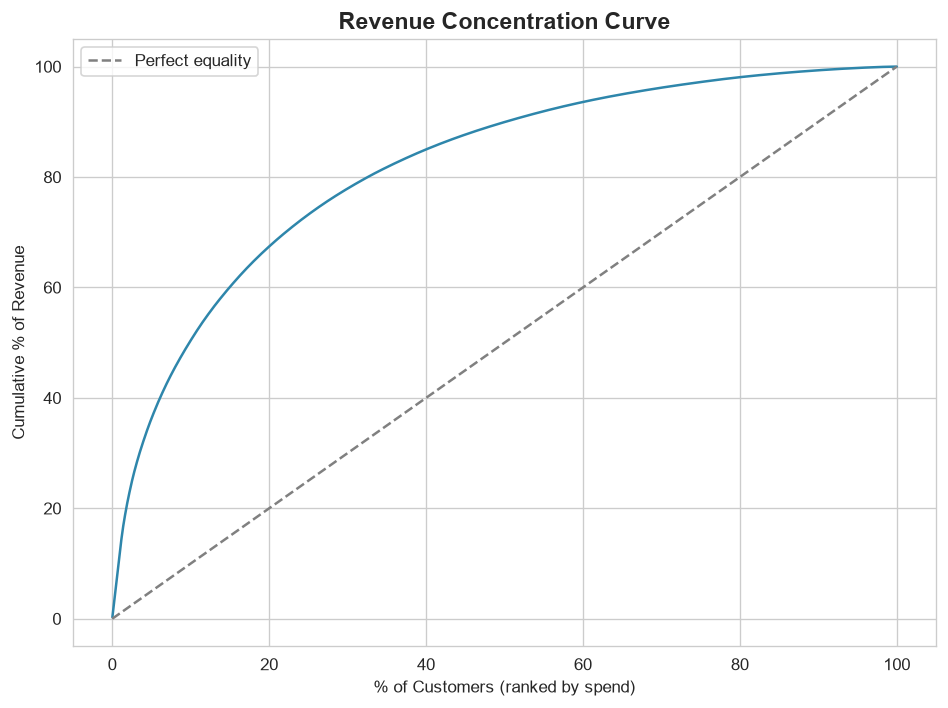

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rfm_sorted["customer_rank_pct"], rfm_sorted["cumulative_revenue_pct"], color="#2E86AB")
ax.plot([0, 100], [0, 100], linestyle="--", color="gray", label="Perfect equality")
ax.set_xlabel("% of Customers (ranked by spend)")
ax.set_ylabel("Cumulative % of Revenue")
ax.set_title("Revenue Concentration Curve", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** Revenue is heavily concentrated — the top 10% of customers generate 50.4% of 
total revenue, and the top 20% generate 67.4%. The curve bows sharply above the equality line 
in its first 10-20%, then flattens considerably, confirming that a relatively small group of 
customers carries the majority of the business's revenue. This concentration reinforces the 
CLV findings: losing even a handful of customers from the top decile would have an outsized 
revenue impact, making retention of this group a higher business priority than broad-based 
retention spread evenly across the full customer base.

## 4. Churn Risk by Segment

In [7]:
CHURN_THRESHOLD_DAYS = 90

at_risk = rfm[rfm["recency"] > CHURN_THRESHOLD_DAYS]
at_risk_by_segment = at_risk.groupby("segment_name").agg(
    at_risk_customers=("customer_id", "count"),
    at_risk_revenue=("monetary", "sum"),
).round(2)

print(f"Total at-risk customers (>{CHURN_THRESHOLD_DAYS} days since last purchase): {len(at_risk):,} "
      f"({len(at_risk)/len(rfm)*100:.1f}% of base)")
print(f"Total at-risk historical revenue: {at_risk['monetary'].sum():,.2f}")
print()
at_risk_by_segment

Total at-risk customers (>90 days since last purchase): 1,449 (33.4% of base)
Total at-risk historical revenue: 930,249.35



,at_risk_customers,at_risk_revenue
segment_name,,
At-Risk,393,334211.72
Champions,4,64732.67
New / Low-Engagement,1038,456867.29
Potential Loyalists,14,74437.67


**Takeaway:** At-risk customers are concentrated by count in the New/Low-Engagement segment (1,038 of 1,449, or 72%), but not by value — that group's at-risk revenue per customer is low (~₦440). The real warning sign is smaller: only 4 Champions and 14 Potential Loyalists have crossed the 90-day inactivity threshold, yet together they represent ₦139,170.34 in at-risk revenue — roughly 19x the per-customer stakes of the New/Low-Engagement group. This confirms churn risk should be triaged by value, not raw count: a small number of previously high-value customers going quiet is a more urgent problem than a much larger group of low-engagement customers doing the same.

## 5. Save Final Output (for SQL / dashboard)

In [8]:
rfm.to_csv("../data/customer_segments.csv", index=False)
print("Updated ../data/customer_segments.csv with CLV columns added")
print("This file is now ready to load into SQLite/Power BI (see sql/ and dashboard/)")

Updated ../data/customer_segments.csv with CLV columns added
This file is now ready to load into SQLite/Power BI (see sql/ and dashboard/)
